# Fine-tune an LLM with Differential Privacy

This notebook fine-tunes DistilGPT-2 on AG News using LoRA adapters
with DP-SGD. It exercises the full production workflow: adaptive
clipping, truncated Poisson sampling, microbatching, and DP-aware optimization.

**Prerequisites:** [DP-SGD Training](dp_sgd_training.ipynb),
[Sampling & Microbatching](sampling_and_microbatching.ipynb).

**Components exercised:** `make_functional` with `partition_trainable`,
`adaptive_clipped_grad`, `PoissonSampler`, `opake.optimizers.adamw` (DP-aware bias correction),
`dpsgd_acc.poisson` (truncated form), PEFT LoRA.
**Runtime:** ~2 minutes on CPU.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchopt
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader, TensorDataset, default_collate
from transformers import AutoModelForCausalLM, AutoTokenizer

import opake.accounting as acc
import opake.dpsgd.accounting as dpsgd_acc
from opake.dpsgd.noise import gaussian_noise
from opake.dpsgd.sampling import PoissonSampler
from opake.functional import empty_collate, make_functional
from opake.optimizers import adamw
from opake.dpsgd.clipping import adaptive_clipped_grad
from opake.patches import apply_model_patches, apply_runtime_patches
from opake.random import key

torch.manual_seed(42)
np.random.seed(42)

W0804 07:01:30.298000 1287 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


## Configuration

In [2]:
MODEL_NAME = "distilgpt2"
LORA_R = 8
LORA_ALPHA = 16

NUM_STEPS = 20
BATCH_SIZE = 8
PUBLIC_DATASET_SIZE = 500
FRACTION_NOISE_STD = 0.05
MAX_BATCH_SIZE = 12
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.01
MICROBATCH_SIZE = 4
MAX_LENGTH = 64

CLIP_NORM = 0.1
NOISE_MULTIPLIER = 1.5
TARGET_DELTA = 1e-5

LOG_INTERVAL = 5

## Load model and apply LoRA

LoRA reduces the number of trainable parameters to ~0.5% of the full
model, which keeps per-example gradient norms small and makes clipping
more effective.

In [3]:
apply_runtime_patches()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    target_modules=["c_attn", "c_proj"],
)
model = get_peft_model(model, lora_config)

# Wire vmap-safe attention/RMS/PEFT kernels into this model instance.
apply_model_patches(model)

model.print_trainable_parameters()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

trainable params: 405,504 || all params: 82,318,080 || trainable%: 0.4926


/Users/evgeny.grigorenko/Workspaces/copilot-worktrees/opake/evgri243-issue-416-execute-documentation-examples-and-valid-38f84f/.venv/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Prepare dataset

In [4]:
dataset = load_dataset("fancyzhx/ag_news", split="train")
# Subsample for tutorial speed (full set is 120k; the workflow is identical at scale).
texts = [ex["text"] for ex in dataset.select(range(PUBLIC_DATASET_SIZE))]

tokenized = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
)

input_ids = tokenized["input_ids"]
attention_mask = tokenized["attention_mask"]
labels = input_ids.clone()
train_dataset = TensorDataset(input_ids, attention_mask, labels)
assert len(train_dataset) == PUBLIC_DATASET_SIZE

print(f"Dataset: {len(train_dataset)} examples, sequence length {MAX_LENGTH}")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset: 500 examples, sequence length 64


## Functional conversion and loss function

`partition_trainable=True` separates the LoRA weights (trainable) from
the frozen base model, so only the LoRA gradients are clipped and
noised.

In [5]:
fmodel, trainable_params, frozen_params = make_functional(
    model,
    disable_autograd_tracking=True,
    partition_trainable=True,
)

trainable_count = sum(p.numel() for p in trainable_params.values())
frozen_count = sum(p.numel() for p in frozen_params.values())
print(f"Trainable: {trainable_count:,}  Frozen: {frozen_count:,}")


def per_example_loss(trainable, frozen, ids, mask, labels):
    all_params = {**frozen, **trainable}
    out = fmodel(
        all_params,
        ids.unsqueeze(0),
        attention_mask=mask.unsqueeze(0),
        labels=labels.unsqueeze(0),
    )
    return out.loss

Trainable: 405,504  Frozen: 81,912,576


## Sampler, clipping, noise, and optimizer

In [6]:
sample_rate = BATCH_SIZE / PUBLIC_DATASET_SIZE

sampler = PoissonSampler(
    train_dataset,
    sample_rate=sample_rate,
    truncated_batch_size=MAX_BATCH_SIZE,
    n_steps=NUM_STEPS,
    key=key(42),
)
collate = empty_collate(default_collate)
collate([train_dataset[0]])
train_loader = DataLoader(train_dataset, batch_sampler=sampler, collate_fn=collate)

grad_fn, clip_state = adaptive_clipped_grad(
    per_example_loss,
    argnums=0,
    batch_argnums=(2, 3, 4),
    initial_clipping_norm=CLIP_NORM,
    target_quantile=0.80,
    fraction_noise_std=FRACTION_NOISE_STD,
    microbatch_size=MICROBATCH_SIZE,
    return_aux=True,
    clipping_norm_min=0.01,
    clipping_norm_max=10.0,
    key=key(0),
    normalize_by=BATCH_SIZE,
    expected_batch_size=BATCH_SIZE,
)

noise_fn, noise_state = gaussian_noise(
    noise_multiplier=NOISE_MULTIPLIER,
    key=key(42),
)

optimizer = adamw(
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    noise_bias_correction=True,
)
opt_state = optimizer.init(trainable_params)

step_process = dpsgd_acc.poisson(
    dpsgd_acc.adaclip(
        dpsgd_acc.gaussian(NOISE_MULTIPLIER),
        fraction_noise_std=FRACTION_NOISE_STD,
        expected_batch_size=BATCH_SIZE,
    ),
    sample_rate,
    truncated_batch_size=MAX_BATCH_SIZE,
    dataset_size=PUBLIC_DATASET_SIZE,
)
expected_eps = (step_process * NUM_STEPS).epsilon_at(TARGET_DELTA)
print(f"Expected final epsilon: {expected_eps:.2f}")

Expected final epsilon: 8.99


## Training loop

In [7]:
losses = []
epsilons = []
clip_norms = []

for step, (batch_ids, batch_mask, batch_labels) in enumerate(train_loader):
    # 1. Clipped gradients (adaptive threshold, microbatched).
    #    `grads` is a ClippedPytree carrying the current per-step max_norm.
    (grads, aux), clip_state = grad_fn(
        trainable_params,
        frozen_params,
        batch_ids,
        batch_mask,
        batch_labels,
        state=clip_state,
    )

    # 2. Add noise (sensitivity is read from grads.max_norm).
    noisy_grads, noise_state = noise_fn(grads, noise_state)

    # 3. Optimizer step
    updates, opt_state = optimizer.update(
        noisy_grads,
        opt_state,
        params=trainable_params,
    )
    trainable_params = torchopt.apply_updates(trainable_params, updates)

    # 4. Track privacy
    epsilon = (step_process * (step + 1)).epsilon_at(TARGET_DELTA)

    avg_loss = aux.loss_values.mean().item() if len(batch_ids) else float("nan")
    losses.append(avg_loss)
    epsilons.append(epsilon)
    clip_norms.append(grads.max_norm)

    if (step + 1) % LOG_INTERVAL == 0 or step == 0:
        print(
            f"Step {step + 1:4d}/{NUM_STEPS}  "
            f"loss={avg_loss:.3f}  "
            f"clip={grads.max_norm:.3f}  "
            f"epsilon={epsilon:.2f}"
        )

assert len(epsilons) == NUM_STEPS
assert epsilons[-1] == expected_eps
print(f"\nFinal: loss={losses[-1]:.3f}, epsilon={epsilons[-1]:.2f}")

/workspaces/jbr-fed-privacy/opaque-issue-1046/.venv/lib/python3.11/site-packages/transformers/integrations/sdpa_attention.py:158: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:82.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


/workspaces/jbr-fed-privacy/opaque-issue-1046/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:82.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step    1/20  loss=5.246  clip=0.013  epsilon=6.04


Step    5/20  loss=6.463  clip=0.014  epsilon=7.61


Step   10/20  loss=6.610  clip=0.019  epsilon=8.27


Step   15/20  loss=5.686  clip=0.023  epsilon=8.68


Step   20/20  loss=6.274  clip=0.030  epsilon=8.99

Final: loss=6.274, epsilon=8.99


## Results

The ε values account for the randomized model updates and adaptive clipping
thresholds under the stated public dataset size and capped Poisson sampler.
Losses and other raw diagnostics here use public AG News data; omit them for
private data and use fresh, secret randomness.

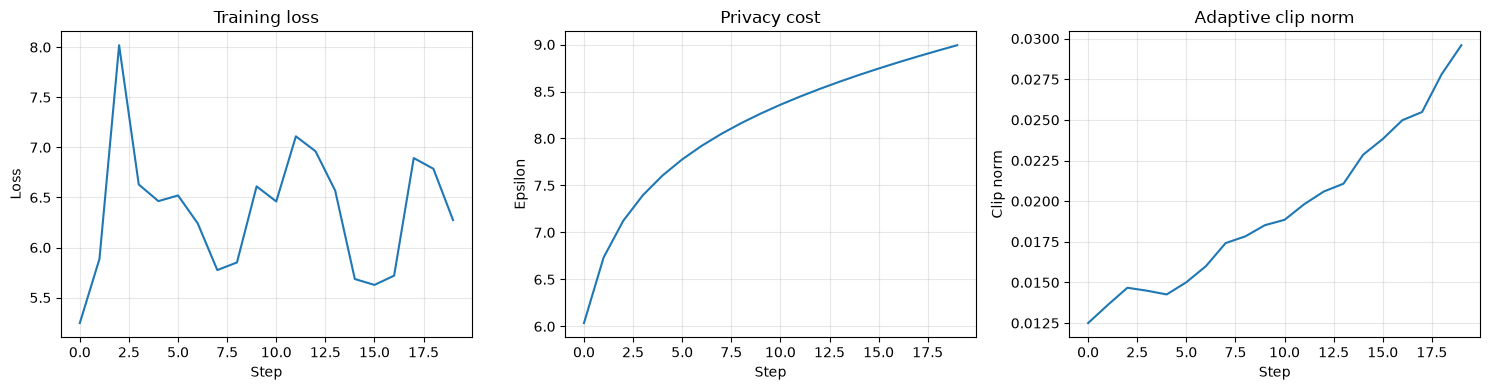

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epsilons)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Epsilon")
axes[1].set_title("Privacy cost")
axes[1].grid(alpha=0.3)

axes[2].plot(clip_norms)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Clip norm")
axes[2].set_title("Adaptive clip norm")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Key choices for LLM fine-tuning with DP:

- **LoRA** reduces trainable parameters to <1% of the model, keeping
  gradient norms small.
- **Adaptive clipping** (`adaptive_clipped_grad`) avoids manual tuning
  of the clip threshold.
- **Truncated Poisson sampling** bounds memory while preserving privacy
  amplification.
- **Microbatching** (`microbatch_size`) further reduces peak memory.
- **`partition_trainable`** ensures only LoRA weights are clipped and
  noised.

For hyperparameter guidance, see the
[HuggingFace Compatibility guide](../user-guide/huggingface/index.md).